In [1]:
import pandas as pd
import matplotlib.pyplot as plt

transactions = pd.read_csv("../data/clean/transactions_clean.csv")

transactions["date"] = pd.to_datetime(transactions["date"])

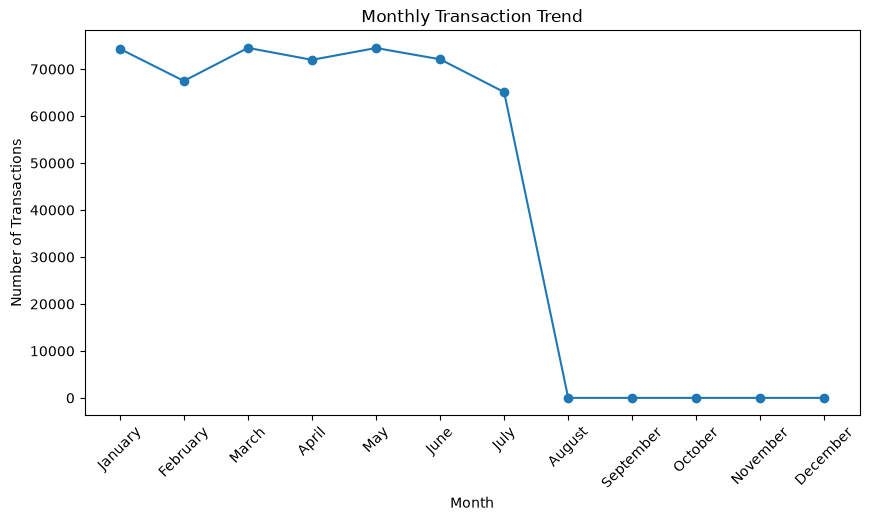

In [ ]:
transactions["month"] = transactions["date"].dt.month_name()

month_order = [
    "January", "February", "March",
    "April", "May", "June", "July",
    "August", "September", "October",
    "November", "December"]

transactions["month"] = pd.Categorical(
    transactions["month"],
    categories=month_order,
    ordered=True
)

month = transactions["month"].value_counts().sort_index()

plt.figure(figsize=(10,5))
plt.plot(month.index.astype(str), month.values, marker="o")

plt.title("Monthly Transaction Trend")
plt.xlabel("Month")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=45)

plt.show()

Steady volume in H1: Transactions remain consistently high from January through July, fluctuating closely between 65,000 and 75,000 transactions per month.

Sharp drop to zero in August: Starting in August, transactions plunge directly to 0 and remain completely flat through December, indicating either incomplete annual data collection or a system cutoff mid-year.

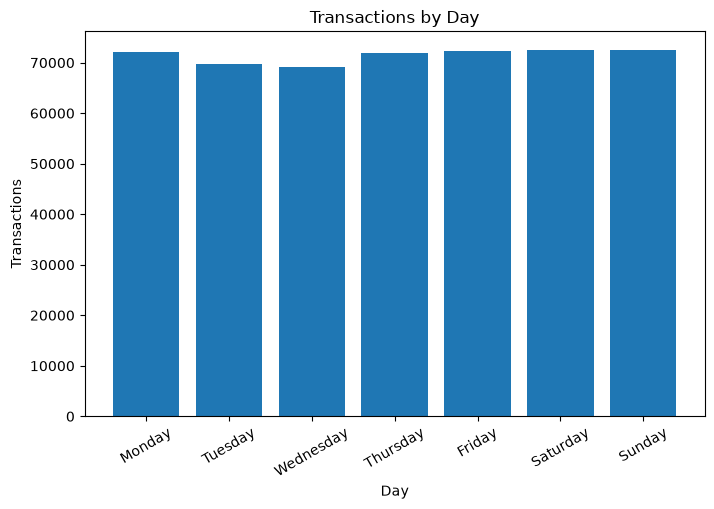

In [3]:
transactions["day_name"] = transactions["date"].dt.day_name()

day_order = [
    "Monday","Tuesday","Wednesday",
    "Thursday","Friday","Saturday","Sunday"]

transactions["day_name"] = pd.Categorical(
    transactions["day_name"],
    categories=day_order,
    ordered=True
)

day = transactions["day_name"].value_counts().sort_index()

plt.figure(figsize=(8,5))
plt.bar(day.index.astype(str), day.values)

plt.title("Transactions by Day")
plt.xlabel("Day")
plt.ylabel("Transactions")

plt.xticks(rotation=30)

plt.show()

Remarkably uniform volume: Transaction activity is nearly uniform across all seven days, holding a steady baseline of around 70,000 to 72,000 transactions per day.

Slight weekend/end-of-week preference: Volume dips slightly on Tuesday and Wednesday (~69,000) before creeping up marginally from Friday through Sunday (~72,500), showing almost no day-of-week seasonality.

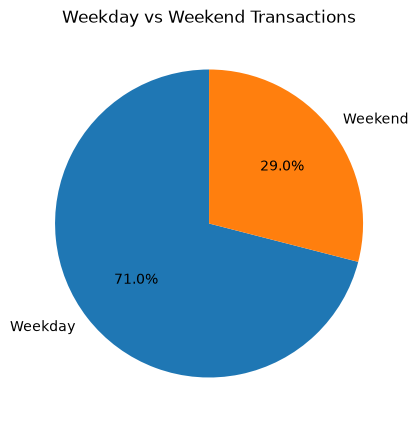

In [4]:
transactions["is_weekend"] = (
    transactions["date"].dt.dayofweek >= 5
)

weekend = transactions["is_weekend"].value_counts()

plt.figure(figsize=(5,5))
plt.pie(
    weekend,labels=["Weekday","Weekend"],autopct="%1.1f%%",startangle=90)

plt.title("Weekday vs Weekend Transactions")

plt.show()

Weekday majority: Weekday transactions account for 71.0% of the total volume.

Proportional split: Weekend transactions make up the remaining 29.0%.

Even daily distribution: Since weekdays cover 5 out of 7 days (~71.4% of the week) and weekends cover 2 days (~28.6%), the volume per day is almost perfectly identical regardless of whether it's a weekday or a weekend.

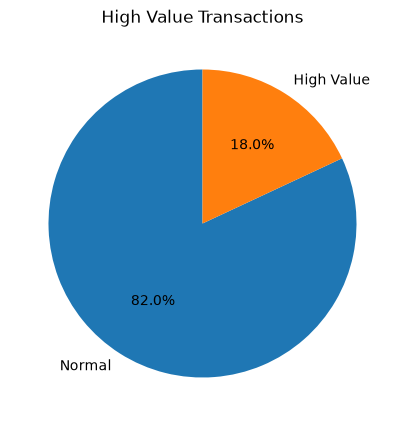

In [5]:
transactions["high_value_transaction"] = (transactions["amount"] >= 10000)

high = transactions["high_value_transaction"].value_counts()

plt.figure(figsize=(5,5))
plt.pie(high,labels=["Normal","High Value"],autopct="%1.1f%%",startangle=90)

plt.title("High Value Transactions")

plt.show()

Normal transactions dominate: The vast majority of activity consists of Normal transactions at 82.0%.

Notable high-value slice: Nearly 1 in 5 transactions (18.0%) are flagged as High Value.

Risk & revenue implication: While high-value transactions make up a smaller share of overall volume, they likely represent a significant portion of the total financial exposure and revenue, warranting tailored monitoring or fraud rules.

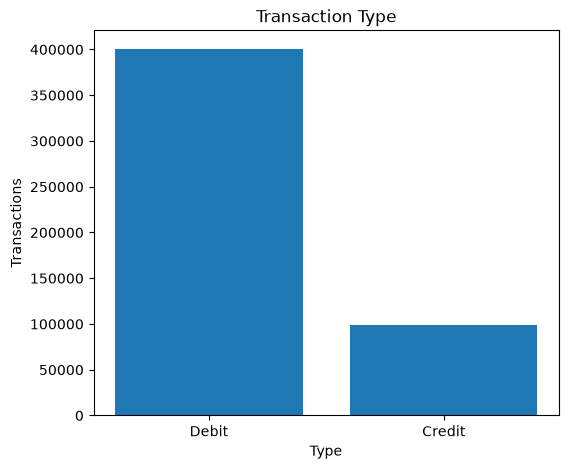

In [6]:
trans_type = transactions["transaction_type"].value_counts()

plt.figure(figsize=(6,5))
plt.bar(trans_type.index, trans_type.values)

plt.title("Transaction Type")
plt.xlabel("Type")
plt.ylabel("Transactions")

plt.show()

Debit transactions dominate: Debit activity leads by a wide margin at 400,000 transactions, accounting for 80% of total transaction volume.

Lower credit frequency: Credit transactions make up the remaining 100,000 transactions (20%), showing a 4-to-1 ratio between money moving out versus coming in.

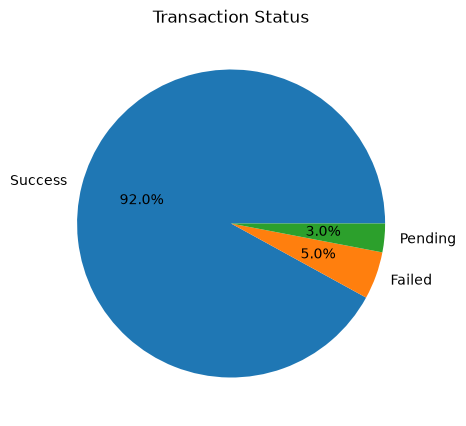

In [8]:
status = transactions["status"].value_counts()

plt.figure(figsize=(5,5))
plt.pie(status,labels=status.index,autopct="%1.1f%%")

plt.title("Transaction Status")

plt.show()

High success rate: The vast majority of operations are completed smoothly, with Success accounting for 92.0% of all transactions.

Minority exceptions: Friction remains low overall, with Failed transactions making up 5.0% and Pending transactions representing the remaining 3.0%.

Reliable processing pipeline: A combined non-success rate of just 8.0% indicates a stable payment or processing system, though investigating the 5.0% failure rate could yield actionable operational improvements.

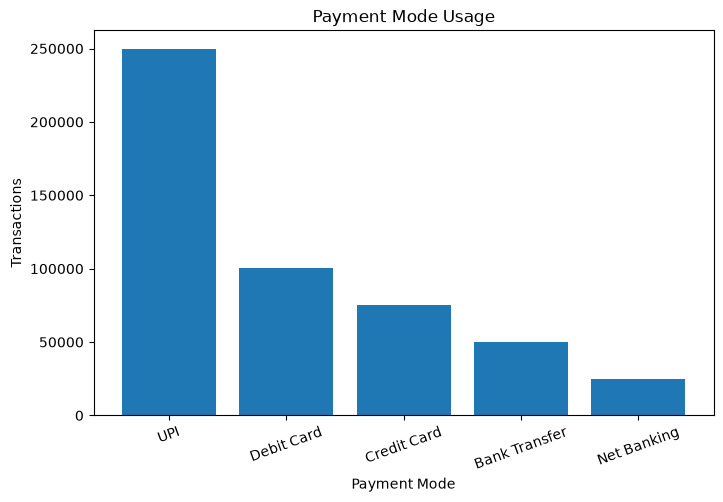

In [9]:
payment = transactions["payment_mode"].value_counts()

plt.figure(figsize=(8,5))
plt.bar(payment.index, payment.values)

plt.title("Payment Mode Usage")
plt.xlabel("Payment Mode")
plt.ylabel("Transactions")

plt.xticks(rotation=20)

plt.show()

UPI heavily dominates usage: UPI is by far the most preferred payment method, leading with 250,000 transactions—equal to all other payment methods combined.

Tiered secondary channels: Card options follow next with Debit Card (100,000) and Credit Card (75,000), while traditional methods see the lowest adoption at Bank Transfer (50,000) and Net Banking (25,000).

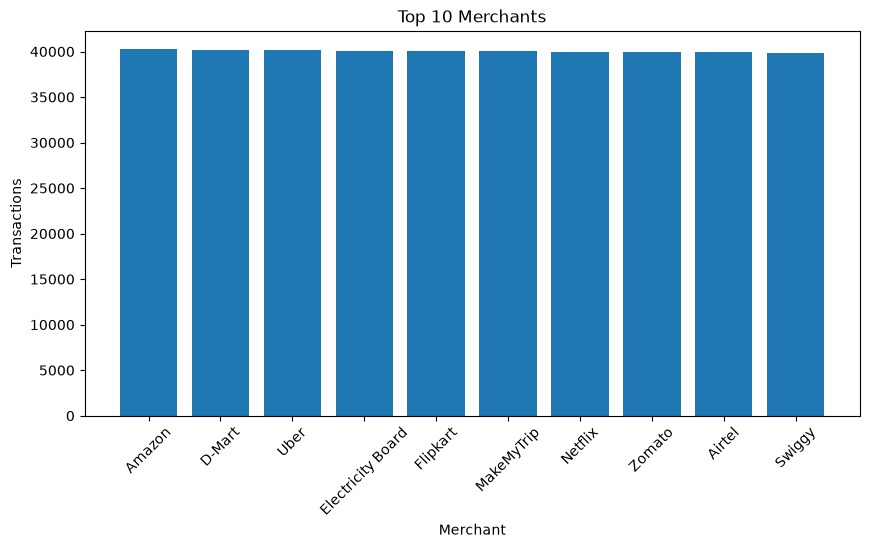

In [10]:
merchant = transactions["merchant"].value_counts().head(10)

plt.figure(figsize=(10,5))
plt.bar(merchant.index, merchant.values)

plt.title("Top 10 Merchants")
plt.xlabel("Merchant")
plt.ylabel("Transactions")

plt.xticks(rotation=45)

plt.show()

Nearly uniform distribution: Transaction volume across all top 10 merchants is remarkably balanced, with each merchant sitting right around 40,000 transactions.

Diverse ecosystem coverage: The top list spans e-commerce (Amazon, Flipkart), retail (D-Mart), utilities (Electricity Board, Airtel), travel/mobility (Uber, MakeMyTrip), food delivery (Zomato, Swiggy), and streaming (Netflix).

Synthetic data signature: Such an even spread across completely distinct industries strongly points to balanced synthetic data generation or a uniform sampling cap per top merchant.